计算结果按照倾角 5 度为间隔编程画图展示

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


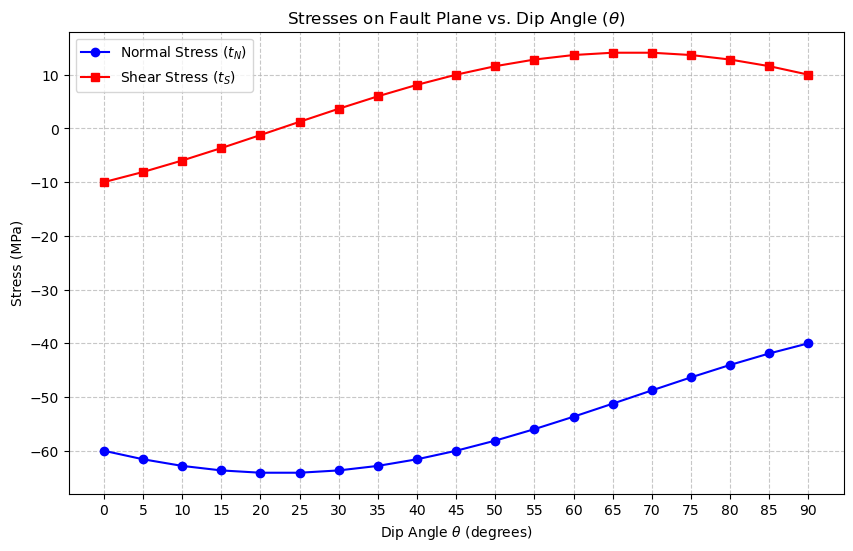

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置角度范围 0 到 90 度，间隔 5 度
thetas_deg = np.arange(0, 95, 5)
thetas_rad = np.radians(thetas_deg)

# 计算正应力 sigma_N 和 剪应力 t_S
sigma_N = -50 - 10 * np.cos(2 * thetas_rad) - 10 * np.sin(2 * thetas_rad)
t_S = 10 * np.sin(2 * thetas_rad) - 10 * np.cos(2 * thetas_rad)

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(thetas_deg, sigma_N, 'bo-', label='Normal Stress ($t_N$)')
plt.plot(thetas_deg, t_S, 'rs-', label='Shear Stress ($t_S$)')

plt.title('Stresses on Fault Plane vs. Dip Angle ($\\theta$)')
plt.xlabel('Dip Angle $\\theta$ (degrees)')
plt.ylabel('Stress (MPa)')
plt.xticks(np.arange(0, 95, 5))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


正应力的计算公式为:
$$\tau_n = \tau_{11}\cos^2\phi - 2\tau_{12}\sin\phi\cos\phi + \tau_{22}\sin^2\phi$$

剪应力 :
$$\tau_s = (\tau_{11} - \tau_{22})\sin\phi\cos\phi + \tau_{12}(\cos^2\phi - \sin^2\phi)$$


In [ ]:
import numpy as np
import pandas as pd

landers = {'t11': 3294, 't22': 81351, 't12': -45643.5}

longterm = {'t11': 9200385, 't22': 1192035, 't12': 330750}

def calculate_fault_stresses(t11, t22, t12, azimuth_deg):
    """计算特定方位角直立断层上的正应力和剪应力"""
    phi = np.radians(azimuth_deg)
    
    
    tau_n = 0.5 * (t11 + t22) + 0.5 * (t11 - t22) * np.cos(2 * phi) - t12 * np.sin(2 * phi)
    tau_s = 0.5 * (t11 - t22) * np.sin(2 * phi) + t12 * np.cos(2 * phi)
    return tau_n, tau_s

results = []

for az in range(0, 180, 10):
    n_L, s_L = calculate_fault_stresses(landers['t11'], landers['t22'], landers['t12'], az)
    n_LT, s_LT = calculate_fault_stresses(longterm['t11'], longterm['t22'], longterm['t12'], az)
    
    results.append({
        'Azimuth (deg)': az,
        'Landers Normal (kPa)': n_L / 1000,
        'Landers Shear (kPa)': s_L / 1000,
        'Long-term Normal (MPa)': n_LT / 1000000,
        'Long-term Shear (MPa)': s_LT / 1000000
    })

df = pd.DataFrame(results)
print(df.round(2).to_string(index=False))

 Azimuth (deg)  Landers Normal (kPa)  Landers Shear (kPa)  Long-term Normal (MPa)  Long-term Shear (MPa)
             0                  3.29               -45.64                    9.20                   0.33
            10                 21.26               -56.24                    8.85                   1.68
            20                 41.76               -60.05                    8.05                   2.83
            30                 62.34               -56.62                    6.91                   3.63
            40                 80.50               -46.36                    5.57                   4.00
            50                 94.05               -30.51                    4.18                   3.89
            60                101.37               -10.98                    2.91                   3.30
            70                101.56                 9.88                    1.92                   2.32
            80                 94.61                29.

对于 Landers 地震同震应力变化： 最大剪应力出现在方位角 20° 和 110°（绝对值约为 60.05 kPa）。

对于 1000 年长期累积应力： 最大剪应力出现在方位角 40° 和 130°（绝对值约为 4.00 MPa）

In [5]:
import numpy as np
import pandas as pd

yearly_stress = {'t11': 9.20, 't22': 1.19, 't12': 0.33}
mu_s = 0.2 

def calculate_yearly_cff(t11, t22, t12, azimuth_deg, mu):
    
    phi = np.radians(azimuth_deg)
    
    tau_n = 0.5 * (t11 + t22) + 0.5 * (t11 - t22) * np.cos(2 * phi) - t12 * np.sin(2 * phi)
    tau_s = 0.5 * (t11 - t22) * np.sin(2 * phi) + t12 * np.cos(2 * phi)
    

    delta_cff = abs(tau_s) + mu * tau_n
    return tau_n, tau_s, delta_cff

results = []
for az in range(0, 180, 10):
    n, s, cff = calculate_yearly_cff(yearly_stress['t11'], yearly_stress['t22'], yearly_stress['t12'], az, mu_s)
    
    results.append({
        'Azimuth (deg)': az,
        'Yearly ΔNormal (kPa/yr)': n,
        'Yearly ΔShear (kPa/yr)': s,
        'Yearly ΔCFF (kPa/yr)': cff
    })
df = pd.DataFrame(results)
print(df.round(2).to_string(index=False))

 Azimuth (deg)  Yearly ΔNormal (kPa/yr)  Yearly ΔShear (kPa/yr)  Yearly ΔCFF (kPa/yr)
             0                     9.20                    0.33                  2.17
            10                     8.85                    1.68                  3.45
            20                     8.05                    2.83                  4.44
            30                     6.91                    3.63                  5.02
            40                     5.57                    4.00                  5.11
            50                     4.17                    3.89                  4.72
            60                     2.91                    3.30                  3.88
            70                     1.91                    2.32                  2.70
            80                     1.32                    1.06                  1.32
            90                     1.19                   -0.33                  0.57
           100                     1.54               

In [ ]:
import numpy as np
import pandas as pd

landers = {'t11': 3.29, 't22': 81.35, 't12': -45.64}
longterm = {'t11': 9200.39, 't22': 1192.04, 't12': 330.75} 
yearly = {'t11': 9.20, 't22': 1.19, 't12': 0.33}
mu_s = 0.2

def calc_stresses(t11, t22, t12, azimuth_deg):
    phi = np.radians(azimuth_deg)
    tau_n = 0.5 * (t11 + t22) + 0.5 * (t11 - t22) * np.cos(2 * phi) - t12 * np.sin(2 * phi)
    tau_s = 0.5 * (t11 - t22) * np.sin(2 * phi) + t12 * np.cos(2 * phi)
    return tau_n, tau_s

results = []

for az in range(0, 180, 10):
    n_L, s_L = calc_stresses(landers['t11'], landers['t22'], landers['t12'], az)
    n_1000, s_1000 = calc_stresses(longterm['t11'], longterm['t22'], longterm['t12'], az)
    n_a, s_a = calc_stresses(yearly['t11'], yearly['t22'], yearly['t12'], az)
    
    cff_a = abs(s_a) + mu_s * n_a
    
    delta_cff_instant = (abs(s_1000 + s_L) - abs(s_1000)) + mu_s * n_L
    
    dt_years = delta_cff_instant / cff_a
    
    sign_agree = (s_1000 * s_L) > 0
    
    results.append({
        'Azimuth': az,
        'Sign Agree?': 'Yes' if sign_agree else 'No',
        'Instant ΔCFF (kPa)': delta_cff_instant,
        'Δt (Years)': dt_years
    })

df = pd.DataFrame(results)
print(df.round(2).to_string(index=False))

 Azimuth Sign Agree?  Instant ΔCFF (kPa)  Δt (Years)
       0          No              -44.98      -20.73
      10          No              -51.99      -15.07
      20          No              -51.70      -11.65
      30          No              -44.15       -8.80
      40          No              -30.26       -5.92
      50          No              -11.70       -2.48
      60          No                9.29        2.39
      70         Yes               30.19       11.16
      80         Yes               48.46       36.62
      90          No              -29.37      -51.71
     100          No              -43.56      -21.90
     110          No              -51.47      -15.62
     120          No              -52.16      -12.05
     130          No              -45.53       -9.17
     140          No              -32.39       -6.31
     150          No              -14.33       -2.98
     160         Yes                6.49        1.62
     170         Yes               27.55      

PFO 附近没有出现地震活动高峰，仅仅意味着当地没有那些既处于 CFF 增加区，又恰好处于临界破裂边缘的断层。这并不能作为否定 CFF 阈值模型的证据；相反，它是断层力学中非常典型且合理的现象。